<center>


<div style="display: flex; justify-content: center;">
    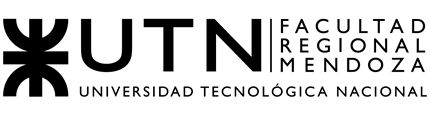
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Ingeniería en Electrónica</strong></p>
        <p><strong>Ingeniería en Telecomunicaciones</strong></p>
    </div>
</center>

# Módulo 8 — Matplotlib

En el Módulo 7 aprendiste a **generar** arrays: un eje de tiempo con `linspace`, una senoidal con `np.sin`, miles de muestras en dos líneas. Pero mirarlas con `print` no ayuda mucho: un gráfico de una señal te dice en un vistazo lo que una columna de 200 números te oculta.

De eso se encarga **Matplotlib**: la librería estándar de Python para dibujar gráficos. Se integra de manera natural con NumPy — cualquier array se puede graficar tal cual, sin conversiones — y su API es deliberadamente parecida a la de MATLAB, lo que la vuelve familiar apenas la ves.

Los temas de este módulo son:

| Tema | Para qué sirve |
|------|----------------|
| `import matplotlib.pyplot as plt` | Cargar la librería con su alias convencional |
| `plt.plot(x, y)` | Graficar una curva uniendo puntos |
| `title`, `xlabel`, `ylabel`, `grid` | Que el gráfico cuente su historia solo |
| Varias curvas y leyendas | `label=` + `plt.legend()` |
| `plt.figure(figsize=...)` | Controlar el tamaño de la figura |
| `plt.subplots(filas, columnas)` | Varios paneles en una misma figura |
| `plt.stem(n, x)` | Señales discretas (un palito por muestra) |
| `plt.scatter(x, y)` | Puntos sueltos en el plano |

> **Conexión con el Módulo 7.** Todo lo que grafiques va a salir de un array de NumPy. Si te perdés en algún paso, es casi seguro un tema de cómo se generó el array, no del gráfico.

## 1. Cargar la librería

La convención es cargar el submódulo `pyplot` con el alias `plt`. `pyplot` es la parte de Matplotlib con la que vamos a trabajar todo este módulo: expone funciones simples (`plot`, `title`, `show`...) que se encadenan para construir un gráfico.

También cargamos NumPy porque prácticamente cualquier gráfico que hagamos parte de un array.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

De ahora en adelante, cada vez que escribamos `plt.algo` le estamos pidiendo a Matplotlib una de sus funciones. El alias `plt`, como el `np` de NumPy, es universal: lo vas a ver en casi todo código Python que trabaje con gráficos.

> **Ejecutá esta celda una sola vez** al abrir el notebook. De ahí en adelante, `plt` y `np` quedan disponibles hasta que reinicies el entorno.

## 2. El primer gráfico

La función base es `plt.plot(x, y)`: toma dos arrays del mismo largo y une los puntos $(x_0, y_0), (x_1, y_1), \ldots$ con segmentos de recta.

Empecemos con una parábola:

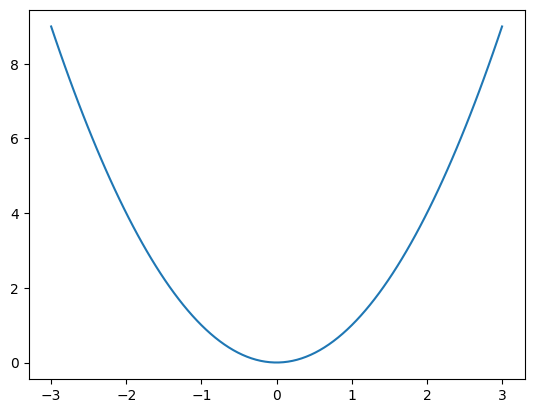

In [2]:
x = np.linspace(-3, 3, 100)
y = x ** 2

plt.plot(x, y)
plt.show()

Tres cosas para notar:

- `x` tiene 100 puntos equiespaciados entre $-3$ y $3$; `y` tiene los cuadrados correspondientes. Son dos arrays del mismo largo.
- `plt.plot(x, y)` hace todo el trabajo: lee los dos arrays y dibuja la curva.
- `plt.show()` le indica a Matplotlib "mostrá ya". En Colab y otros notebooks el gráfico se muestra solo al final de la celda, así que `plt.show()` no siempre es necesario, pero incluirlo es una buena costumbre: deja explícito en qué momento termina el gráfico.

Lo que ves parece una curva suave, pero en realidad son 100 segmentos de recta muy cortos que, al tener los puntos cerca, dan la ilusión de continuidad. Si bajás el número de puntos de `linspace`, la "curva" se vuelve poligonal.

## 3. Títulos, etiquetas y grilla

Un gráfico sin títulos ni etiquetas obliga a quien lo lee a adivinar qué estamos mostrando. Cuatro funciones arreglan eso:

- `plt.title("...")` — título del gráfico.
- `plt.xlabel("...")` — etiqueta del eje horizontal.
- `plt.ylabel("...")` — etiqueta del eje vertical.
- `plt.grid(True)` — dibuja una grilla para leer valores con más precisión.

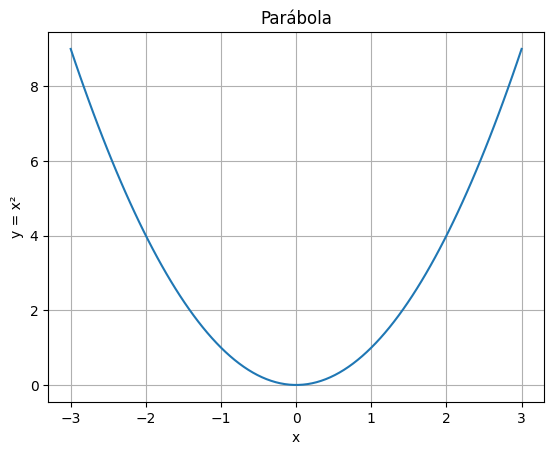

In [3]:
x = np.linspace(-3, 3, 100)
y = x ** 2

plt.plot(x, y)
plt.title("Parábola")
plt.xlabel("x")
plt.ylabel("y = x²")
plt.grid(True)
plt.show()

Estas cuatro llamadas van **antes** de `plt.show()` y operan sobre el último gráfico abierto. El orden entre ellas no importa.

Para el resto del curso vamos a asumir que todo gráfico tiene, como mínimo, título, etiquetas en ambos ejes y grilla. Es una cuestión de higiene: un gráfico sin contexto no sirve.

## 4. Graficar una señal muestreada

La receta más frecuente en este curso es:

1. Armar el eje de tiempos con `linspace`.
2. Calcular la señal como función de ese eje.
3. Graficar con `plot`.

Retomemos la senoidal del Módulo 7:

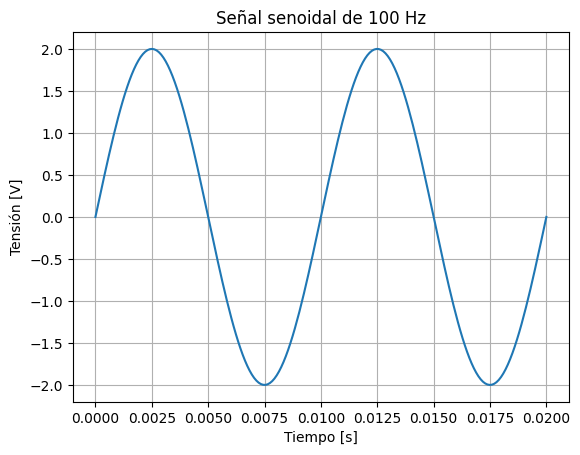

In [4]:
# Parámetros
A = 2          # amplitud en volts
f = 100        # frecuencia en Hz
duracion = 0.02   # 20 ms

# Eje de tiempos y señal
t = np.linspace(0, duracion, 200)
x = A * np.sin(2 * np.pi * f * t)

# Gráfico
plt.plot(t, x)
plt.title("Señal senoidal de 100 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Tensión [V]")
plt.grid(True)
plt.show()

Un detalle importante, que ya veníamos comentando: aunque la curva se ve "continua", en realidad son 200 puntos discretos conectados por segmentos. Matplotlib no sabe nada de la señal original; sólo conecta las muestras que le diste. Si el muestreo es lo suficientemente denso, el resultado parece continuo. Si es pobre, los segmentos se ven a ojo. En el lab de muestreo vamos a revisitar con más profundidad este tema.

### Actividad 1: graficar una senoidal

Partiendo de la receta anterior, graficá la señal

$$x(t) = 3 \cdot \sin(2\pi \cdot 50 \cdot t)$$

durante 40 ms, con 400 puntos.

1. Armá el eje de tiempos con `linspace`.
2. Calculá `x` aplicando la fórmula.
3. Graficá con título `"Senoidal de 50 Hz"`, ejes etiquetados en segundos y volts, y grilla.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# TU CÓDIGO AQUÍ

## 5. Varias señales en un mismo gráfico

Llamadas consecutivas a `plt.plot` **comparten el mismo eje**: todo se dibuja encima, cada curva con un color distinto automáticamente asignado.

Para distinguirlas hace falta una *leyenda*. Se arma en dos pasos:

1. Pasarle a cada `plt.plot` un argumento `label="..."` con el nombre de esa curva.
2. Llamar a `plt.legend()` antes de `plt.show()`.

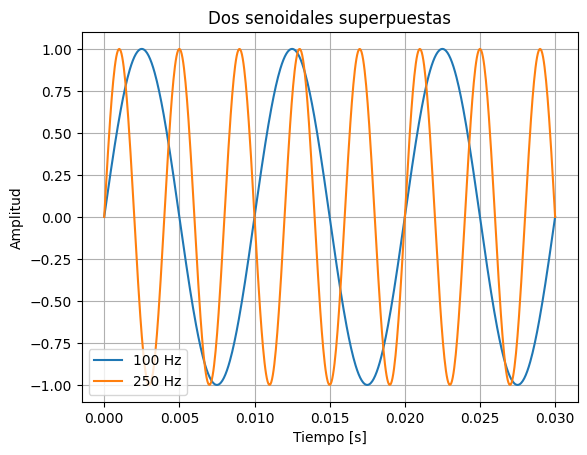

In [6]:
t = np.linspace(0, 0.03, 600)
x1 = np.sin(2 * np.pi * 100 * t)
x2 = np.sin(2 * np.pi * 250 * t)

plt.plot(t, x1, label="100 Hz")
plt.plot(t, x2, label="250 Hz")
plt.title("Dos senoidales superpuestas")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

Si querés forzar un color concreto, `plt.plot` acepta un argumento `color`:

```python
plt.plot(t, x1, color="red", label="100 Hz")
```

Y también acepta un "código corto" estilo MATLAB combinando color y estilo de línea, por ejemplo `"r--"` (rojo, línea entrecortada) o `"g-."` (verde, punto y raya). Son útiles para apurar un gráfico; para trabajos más prolijos conviene pasar los argumentos por nombre.

### Actividad 2: señal original y su versión amplificada

Simulemos la entrada y la salida de un amplificador de ganancia $G = 3$.

1. Generá `t` con 600 puntos entre 0 y 20 ms.
2. Generá `entrada = np.sin(2 * np.pi * 200 * t)` (señal a 200 Hz, amplitud 1).
3. Generá `salida = 3 * entrada`.
4. Graficá las dos señales en un mismo gráfico, con leyendas `"Entrada"` y `"Salida (G = 3)"`, ejes etiquetados y grilla.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# TU CÓDIGO AQUÍ

## 6. Controlar el tamaño de la figura

Por defecto los gráficos salen cuadrados y más bien chicos. Para señales temporales suele servir algo ancho y bajo, que deje ver varios ciclos sin apretarse.

Se controla con `plt.figure(figsize=(ancho, alto))`, **antes** del primer `plt.plot`. Las medidas están en pulgadas.

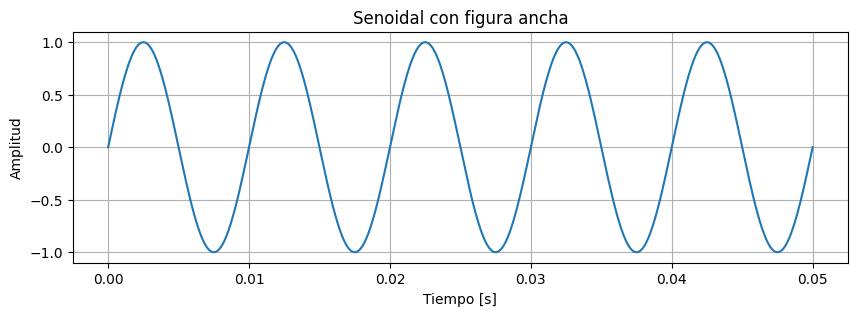

In [8]:
t = np.linspace(0, 0.05, 500)
x = np.sin(2 * np.pi * 100 * t)

plt.figure(figsize=(10, 3))
plt.plot(t, x)
plt.title("Senoidal con figura ancha")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

## 7. Varios paneles: `plt.subplots`

A veces queremos dos gráficos **distintos** en la misma figura (por ejemplo, la señal arriba y algo derivado de ella abajo). Para eso se usa `plt.subplots(filas, columnas)`, que devuelve dos cosas:

- una **figura** (el lienzo completo),
- un **array de ejes** (`axs`), uno por panel.

Sobre cada `axs[i]` llamamos sus propios métodos, que tienen nombres ligeramente distintos a los que venimos usando: `ax.plot`, `ax.set_title`, `ax.set_xlabel`, `ax.set_ylabel`, `ax.grid`. Los prefijos `set_` son una particularidad de esta API orientada a objetos.

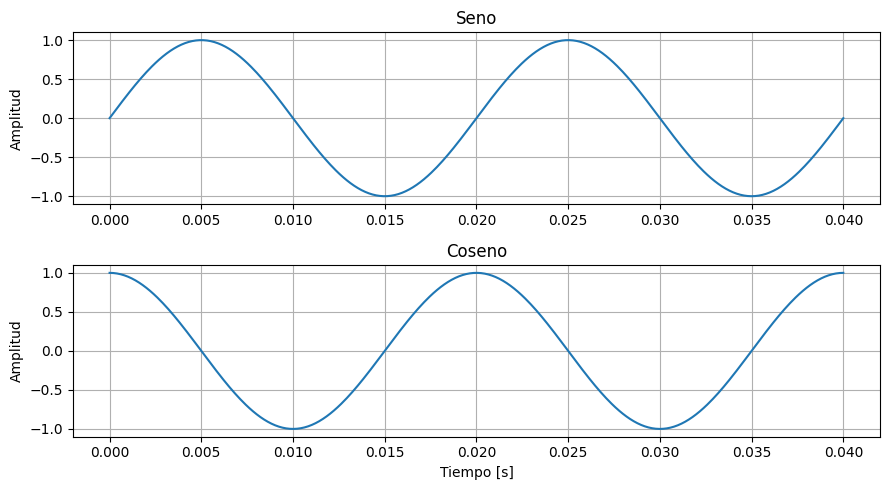

In [9]:
t = np.linspace(0, 0.04, 400)
seno = np.sin(2 * np.pi * 50 * t)
coseno = np.cos(2 * np.pi * 50 * t)

fig, axs = plt.subplots(2, 1, figsize=(9, 5))

axs[0].plot(t, seno)
axs[0].set_title("Seno")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)

axs[1].plot(t, coseno)
axs[1].set_title("Coseno")
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud")
axs[1].grid(True)

plt.tight_layout()
plt.show()

Tres detalles:

- `plt.subplots(2, 1, ...)` arma **2 filas y 1 columna**. Si pusiéramos `(1, 2)` quedarían lado a lado.
- Notá que solo le puse `xlabel` al panel de abajo: los dos paneles comparten el eje x (tiempo), así que alcanza con etiquetarlo una vez.
- `plt.tight_layout()` al final ajusta los márgenes para que los títulos no se superpongan entre paneles. Es casi gratis incluirlo siempre que uses subplots.

### Actividad 3: tensión y potencia instantánea

Una resistencia de $R = 1\ \Omega$ recibe una señal senoidal. Queremos ver en paneles separados la tensión $v(t)$ y la potencia instantánea $p(t) = v^2(t) / R$.

1. Generá `t` con 400 puntos entre 0 y 40 ms.
2. Generá `v = 2 * np.sin(2 * np.pi * 50 * t)`.
3. Calculá `p = v ** 2` (con $R = 1$, queda así de simple).
4. Armá una figura con dos paneles, uno arriba del otro, con `figsize=(9, 5)`. En el panel de arriba graficá `v`; en el de abajo, `p`. Etiquetá ejes y títulos con unidades apropiadas (V para tensión, V² para potencia con $R=1$).

Al mirar el gráfico, fijate en dos cosas: la potencia es **siempre positiva** (es un cuadrado), y oscila al **doble de frecuencia** que la tensión.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# TU CÓDIGO AQUÍ

## 8. Señales discretas: `plt.stem`

Hasta acá graficamos conectando puntos con líneas, lo que es natural cuando la señal de fondo es continua y lo que tenemos son muestras densas. Para una señal **inherentemente discreta** (definida solo en índices enteros $n = 0, 1, 2, \ldots$), unirlos con líneas engaña: sugiere que hay algo entre muestra y muestra cuando no hay nada.

Para estos casos está `plt.stem(n, x)`: dibuja un palito vertical en cada muestra, rematado con un punto. Así queda visualmente claro que la señal vive solo en esos índices.

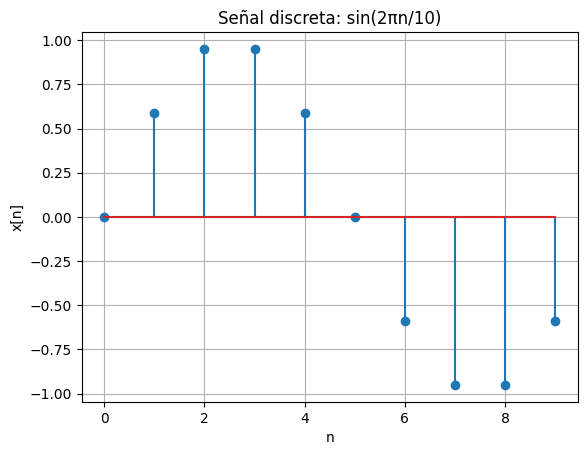

In [11]:
n = np.arange(0, 10)
x_n = np.sin(2 * np.pi * n / 10)

plt.stem(n, x_n)
plt.title("Señal discreta: sin(2πn/10)")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.show()

Resumen rápido:

- Señales continuas muestreadas con muestreo denso → `plt.plot`.
- Señales discretas (o cuando querés resaltar que son muestras individuales) → `plt.stem`.

La elección **comunica** qué tipo de señal estás mostrando, y se convierte en una convención que vas a usar durante toda la cursada.

### Actividad 4: descarga muestreada de un capacitor

Un capacitor se descarga a través de una resistencia. Tomamos muestras a intervalos regulares y obtenemos la secuencia

$$v[n] = V_0 \cdot e^{-n/\tau_n}$$

con $V_0 = 10$ V y $\tau_n = 4$ (constante de tiempo expresada en cantidad de muestras).

1. Generá `n = np.arange(0, 20)`.
2. Calculá `v_n = 10 * np.exp(-n / 4)` aprovechando que `np.exp` opera sobre el array entero.
3. Graficalo con `plt.stem`, título `"Descarga muestreada"`, `xlabel = "n"`, `ylabel = "v[n] [V]"`, grilla.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# TU CÓDIGO AQUÍ

## 9. Puntos en el plano: `plt.scatter`

`plot` y `stem` asumen que hay una secuencia ordenada: a cada valor del eje x le corresponde uno del eje y. A veces lo que querés es graficar **puntos sueltos** en el plano, sin conectarlos ni representar una variable temporal. Para eso sirve `plt.scatter(x, y)`.

Un caso natural: un número complejo $z = a + jb$ se puede ver como un punto $(a, b)$ en el plano. Recordá del Módulo 2 que los complejos tienen los atributos `.real` y `.imag`, que sobre arrays de NumPy devuelven arrays con las partes reales e imaginarias respectivamente.

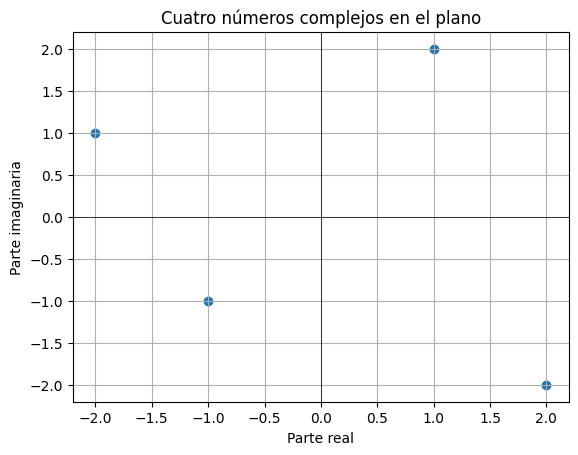

In [13]:
z = np.array([1 + 2j, -2 + 1j, -1 - 1j, 2 - 2j])

plt.scatter(z.real, z.imag)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Cuatro números complejos en el plano")
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.grid(True)
plt.show()

Dos funciones nuevas aparecen aquí:

- `plt.axhline(0, ...)` dibuja una línea **h**orizontal a la altura $y = 0$.
- `plt.axvline(0, ...)` dibuja una línea **v**ertical en $x = 0$.

En el plano complejo son útiles para marcar bien los ejes real e imaginario. El argumento `color="black"` las pone en negro; `linewidth=0.5` las hace finitas para que no compitan con los datos.

### Actividad 5: impedancia en el plano complejo

Medimos la impedancia $Z$ de un componente a cuatro frecuencias distintas y obtenemos estos valores (en ohms):

```python
Z = np.array([5 + 1j, 5 + 3j, 5 + 6j, 5 + 10j])
```

1. Graficá los cuatro puntos con `plt.scatter(Z.real, Z.imag)`.
2. Agregá los ejes real e imaginario con `plt.axhline(0, ...)` y `plt.axvline(0, ...)`.
3. Etiquetá: título `"Impedancia medida"`, `xlabel = "Parte real [Ω]"`, `ylabel = "Parte imaginaria [Ω]"`, grilla.
4. Mirando el gráfico, ¿qué dirías que es constante y qué crece al subir la frecuencia? (No hace falta escribir la respuesta, pero pensala.)

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# TU CÓDIGO AQUÍ

## Cierre

Con lo que aprendiste en este módulo, ya podés convertir cualquier array en una imagen legible:

- `plt.plot(x, y)` para curvas continuas muestreadas densamente.
- `plt.stem(n, x)` para señales discretas.
- `plt.scatter(x, y)` para puntos sueltos (por ejemplo, complejos en el plano).
- `plt.title`, `plt.xlabel`, `plt.ylabel`, `plt.grid`, `plt.legend` para que el gráfico se explique solo.
- `plt.figure(figsize=...)` para elegir el tamaño.
- `plt.subplots(filas, columnas)` para varios paneles en una misma figura.

En los módulos y laboratorios siguientes van a aparecer variantes más específicas (escalas logarítmicas, anotaciones, estilos de línea, gráficos polares, *diagramas de Bode*), pero todas se construyen sobre esta base.

> **Para explorar más:** la galería oficial de Matplotlib está en [matplotlib.org/stable/gallery](https://matplotlib.org/stable/gallery/index.html). Miles de ejemplos, cada uno con su código completo; suele ser más rápido buscar ahí que intentar adivinar el argumento correcto de una función.